<div style="background-color: lightblue; color: black; border: 2px solid black; 
padding: 15px 25px; border-radius: 8px; margin: 10px 0px;">

  <h2 style="color: black; margin: 0px 0px 10px 0px;">
   Rain gauge optimisation
  </h2>

  <hr style="border: 1px solid black; margin: 10px 0px;">

  <p>This code works on defining optimal locations for placements of new rain gauges in the Upper Severn catchment. The placement of the gauges aims to optimise the accuracy with which rainfall over the catchment can be predicted. </p>

  <p><strong>The following data is available:</strong></p>
  <ul>
    <li> 1km HAD-UK gridded annual (?) rainfall data </li>
    <li> Rain gauge data from 10? existing rain gauges</li>
    <li> 30m (?) DEM data: from which slope and aspect can be derived. These are then aggregated to 1km </li>      
  </ul>
<!-- 
  <div style="background-color: white; border-left: 4px solid orange; 
  padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
    <strong>NB:</strong> The threshold for an "unphysical" value is 
    currently set at <strong>150mm/hr</strong> — selected relatively 
    arbitrarily and may need review.
  </div> -->

</div>

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import importlib
import rioxarray

data_dir = "/scratch/hydro4/users/kv25483/FDRI/Rain_gauge_optimisation/Data/"
catchment_Dolwen = gpd.read_file(data_dir + "54080/54080.shp")

import functions
importlib.reload(functions)
from functions import *

### Get rain gauge data

In [2]:
# Load rain gauge metadata
rain_meta_cmd = pd.read_csv(data_dir + "rain_meta_for_CMD.csv")

# Convert to GeoDataFrame (BNG coordinates)
rain_meta_sf = gpd.GeoDataFrame(rain_meta_cmd, geometry=gpd.points_from_xy(rain_meta_cmd["x_2"], rain_meta_cmd["y_2"]),
                                crs="EPSG:27700")

In [3]:
rainfall_gdf_merged = gpd.read_file(data_dir+ "Derived/rainfall_gdf_merged.gpkg")

### Get gridded rainfall data

In [4]:
# Define location of DEM
dem_path = data_dir + "dem_Dolwen.tif"

# 1. Load DEM
with rioxarray.open_rasterio(dem_path, masked=True) as dem_rx:
    dem = dem_rx.squeeze()
    dem_arr = dem.values.astype(float)
    transform = dem.rio.transform()

# 2. Get grid resolution    
dx = transform.a   # pixel width
dy = -transform.e  # pixel height (positive)    

# 3. Compute slope + aspect (drop-in replacement)
dz_dy, dz_dx = np.gradient(dem_arr, dy, dx)

# Slope (degrees)
slope_arr = np.degrees(np.arctan(np.sqrt(dz_dx**2 + dz_dy**2)))

# Aspect (degrees, 0–360)
aspect_arr = np.degrees(np.arctan2(-dz_dx, dz_dy))
aspect_arr = np.where(aspect_arr < 0, 360 + aspect_arr, aspect_arr)


NameError: name 'label_xr' is not defined

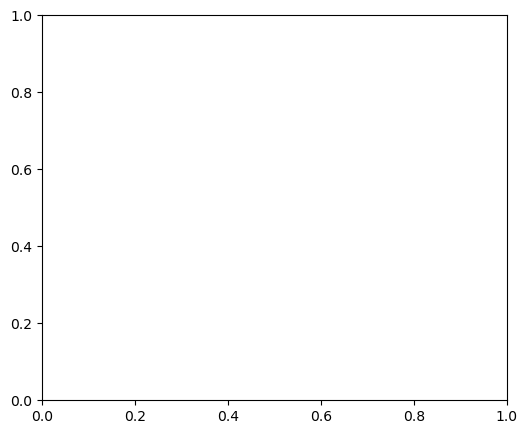

In [5]:
import matplotlib.colors as mcolors

k = 6
import matplotlib

# Build a discrete colormap using only the first k colours of tab10
# cmap = plt.cm.get_cmap("tab10", k)
cmap = matplotlib.colormaps["Set1"].resampled(k)
bounds = np.arange(-0.5, k, 1)  # cluster boundaries: -0.5,0.5,1.5,...,5.5
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(6, 5))
label_xr.plot(ax=ax, cmap=cmap, norm=norm, add_colorbar=True,
              cbar_kwargs={"ticks": np.arange(k), "label": "cluster"})
catchment_Dolwen.boundary.plot(ax=ax, color="black")
ax.axis('off')
ax.set_title(f'K-means clusters (k={k}), native resolution')

In [ ]:
from scipy.spatial.distance import cdist
import rasterio

# 1. Get the cluster centroids (in scaled feature space)
centroids = kmeans.cluster_centers_  # shape (k, n_features)

# 2. For each cluster, find the pixel closest to its centroid
representative_indices = []  # index into X / features / valid pixel list

for cluster_id in range(k):
    # boolean mask of which rows in X belong to this cluster
    cluster_mask = labels == cluster_id
    cluster_points = X[cluster_mask]

    # distance from every point in this cluster to its centroid
    dists = cdist(cluster_points, centroids[cluster_id].reshape(1, -1))

    # index (within the cluster) of the closest point
    best_within_cluster = np.argmin(dists)

    # convert back to index within the full X / valid-pixel array
    global_idx = np.where(cluster_mask)[0][best_within_cluster]
    representative_indices.append(global_idx)

representative_indices = np.array(representative_indices)


# 3. Get row, col positions of valid pixels
valid_rows, valid_cols = np.where(valid_mask)

rep_rows = valid_rows[representative_indices]
rep_cols = valid_cols[representative_indices]

# 4. Convert row/col -> x/y coordinates using the affine transform
rep_xs, rep_ys = rasterio.transform.xy(transform, rep_rows, rep_cols)

# 5. Build a summary table
representative_df = pd.DataFrame({
    "cluster": np.arange(k),
    "row": rep_rows,
    "col": rep_cols,
    "x": rep_xs,
    "y": rep_ys,
    "dem": dem_arr[rep_rows, rep_cols],
    "slope": slope_arr[rep_rows, rep_cols],
    "aspect": aspect_arr[rep_rows, rep_cols],
})

representative_df

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
label_xr.plot(ax=ax, cmap=cmap, norm=norm, add_colorbar=True,
              cbar_kwargs={"ticks": np.arange(k), "label": "cluster"})
catchment_Dolwen.boundary.plot(ax=ax, color="black")
ax.scatter(rep_xs, rep_ys, c="black", edgecolor="white", s=180, marker="*", zorder=5)
ax.axis('off')
ax.set_title(f'K-means clusters (k={k}) with representative pixels')

In [ ]:
cell_centroids = rainfall_gdf_merged.geometry.centroid

<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;"><h3 style="color: black; margin: 0px;"> Decide on one grid cell to represent each cluster </h3>
    
Find one cell to represent each cluster, with constraint on proximity to each other
    
  </div>    
</div>

#### Get the locations of the existing gauges

In [ ]:
existing_gauges = rain_meta_sf.to_crs(rainfall_gdf_merged.crs)
existing_coords = np.array([(g.x, g.y) for g in existing_gauges.geometry])
existing_coords = np.asarray(existing_coords)

#### Get coords of possible location

In [ ]:
cell_coords = np.array([(geom.x, geom.y) for geom in cell_centroids.geometry])

#### For each cluster: get a list of the grid cells in order of how well they represent the cluster

In [ ]:
# ------------------------------------ #
# For each of the clusters, find a list of the cells which 
# would best represent the cluster, in order of appropriateness
# This is based on: how close each grid cell is to the cluster centroid (in feature space)
# ------------------------------------ #
cluster_candidates = {}

# Loop through each grid cell (and the cluster label assigned to it)
for c in np.unique(labels):
    cluster_idx = np.where(labels == c)[0]
    cluster_points = X[cluster_idx]
    
    centroid = kmeans.cluster_centers_[c]
    
    # distances to centroid
    distances = np.linalg.norm(cluster_points - centroid, axis=1)
    
    # sort candidates (best first)
    sorted_idx = cluster_idx[np.argsort(distances)]
    
    cluster_candidates[c] = sorted_idx

#### For each cluster: select a grid cell to represent it, based on ordering above and also spatial proximity to each other

In [ ]:
min_dist=3000

In [ ]:
# --------------------------------------------------
# 1. RUN SINGLE GREEDY (baseline / fixed order)
# --------------------------------------------------
greedy_solution, greedy_failed = greedy_selection(cluster_candidates,cell_coords,existing_coords,min_dist)

# evaluate greedy result
res_greedy = evaluate_solution(greedy_solution,cluster_candidates,cell_coords,existing_coords,min_dist)
print("=== GREEDY BASELINE ===")
print(res_greedy)

# --------------------------------------------------
# 2. RUN SHUFFLE + GREEDY (ensemble search)
# --------------------------------------------------
shuffle_solution = shuffle_greedy(cluster_candidates,cell_coords,existing_coords,min_dist,n_iterations=500)

# evaluate best shuffled solution
res_shuffle = evaluate_solution(shuffle_solution,cluster_candidates,cell_coords,existing_coords,min_dist)
print("\n=== SHUFFLE GREEDY BEST ===")
print(res_shuffle)

# --------------------------------------------------
# 3. Simulated annealing
# --------------------------------------------------
sa_solution = simulated_annealing(initial_solution=shuffle_solution,cluster_candidates=cluster_candidates,
                                  cell_coords=cell_coords,existing_coords=existing_coords,min_dist=min_dist)
res_sa = evaluate_solution(sa_solution,cluster_candidates,cell_coords,existing_coords,min_dist)
print("\n=== SIMULATED ANNEALING")
print(res_sa)

# --------------------------------------------------
# 3. FINAL VALIDATION CHECK (hard consistency test)
# --------------------------------------------------
selected_indices = list(shuffle_solution.values())
coords = cell_coords[selected_indices]

dm = cdist(coords, coords)
np.fill_diagonal(dm, np.inf)

print("\n=== FINAL VALIDATION ===")
print("Min spacing:", dm.min())
print("Spacing violations:", np.sum(dm < min_dist))
print("Existing violations:", np.any(cdist(coords, existing_coords) < min_dist) if len(existing_coords) > 0 else False)


# 4. COVERAGE FAILURES (separate concern)
print("\n=== COVERAGE ===")
print(f"Clusters covered:  {len(shuffle_solution)} / {len(cluster_candidates)}")

failed = [c for c in cluster_candidates if c not in shuffle_solution]
if failed:
    print(f"Failed clusters ({len(failed)}): {failed}")
    print("  → No feasible candidate existed given current placements and min_dist")
else:
    print("All clusters covered.")

# --------------------------------------------------
# 4. SUMMARY OUTPUT
# --------------------------------------------------
print("\n=== SUMMARY ===")
print(f"Clusters covered: {len(shuffle_solution)} / {len(cluster_candidates)}")

# ── Summary table ────────────────────────────────────────────────────────────
# summary = pd.DataFrame({"Original greedy": res_original, "Shuffle+repeat":  res_shuffle,
#     "Simulated anneal":  res_sim_anneal})

In [ ]:
# PLOT
fig,axs=plt.subplots(ncols=2, nrows=2, figsize=(15,15))
axs=axs.flatten()

# #print("\n--- GREEDY ---")
plot_and_check(rainfall_gdf_merged, greedy_solution, cell_centroids, catchment_Dolwen, existing_coords, min_dist, 'Greedy',
               ax=axs[0])
axs[0].axis('off');

#print("\n--- SHUFFLE GREEDY ---")
plot_and_check(rainfall_gdf_merged, shuffle_solution, cell_centroids, catchment_Dolwen, existing_coords, min_dist, 
               'Shuffle greedy', ax=axs[1])
axs[1].axis('off');

#print("\n--- Simulated annealing ---")
plot_and_check(rainfall_gdf_merged, sa_solution, cell_centroids, catchment_Dolwen,  existing_coords, min_dist, 
               'Simulated annealing', ax=axs[2])
axs[2].axis('off');

# #print("\n--- ILP ---")
# #plot_and_check(rainfall_gdf_merged, ilp_solution_result, cell_centroids, existing_coords, min_dist, ax=axs[3])
axs[3].axis('off');
# axs[3].set_axis_off()

In [ ]:
fig,axs=plt.subplots(ncols=4, nrows =2, figsize=(10,4))
axs=axs.flatten()
sns.boxplot(x=rainfall_gdf_merged['cluster'],y=rainfall_gdf_merged['mean_dem'], ax=axs[0])
axs[0].set_xlabel("Cluster")
axs[0].set_ylabel("Mean Elevation")
#axs[0].set_title("Distribution of Elevation by Cluster");

sns.boxplot(x=rainfall_gdf_merged['cluster'],y=rainfall_gdf_merged['mean_slope'], ax=axs[1])
axs[1].set_xlabel("Cluster")
axs[1].set_ylabel("Mean slope")
#axs[1].set_title("Distribution of Slope by Cluster");

sns.boxplot(x=rainfall_gdf_merged['cluster'],y=rainfall_gdf_merged['std_dem'], ax=axs[2])
axs[2].set_xlabel("Cluster")
axs[2].set_ylabel("Std DEM")
#axs[3].set_title("Distribution of Max elevation by Cluster");    

sns.boxplot(x=rainfall_gdf_merged['cluster'],y=rainfall_gdf_merged['std_slope'], ax=axs[3])
axs[3].set_xlabel("Cluster")
axs[3].set_ylabel("Std slope")
#axs[3].set_title("Distribution of Max elevation by Cluster");    

sns.boxplot(x=rainfall_gdf_merged['cluster'],y=rainfall_gdf_merged['mean_daily_rainfall'], ax=axs[4])
axs[3].set_xlabel("Cluster")
axs[3].set_ylabel("Std slope")
#axs[3].set_title("Distribution of Max elevation by Cluster");  

sns.boxplot(x=rainfall_gdf_merged['cluster'],y=rainfall_gdf_merged['mean_annual_rainfall'], ax=axs[5])
axs[3].set_xlabel("Cluster")
axs[3].set_ylabel("Std slope")
#axs[3].set_title("Distribution of Max elevation by Cluster");        

N = 6  # number of plots you actually filled

for i in range(N, len(axs)):
    axs[i].set_visible(False)

fig.tight_layout();

In [ ]:
# import seaborn as sns

# fig,axs=plt.subplots(ncols=2, nrows =2, figsize=(10,10))
# axs=axs.flatten()
# sns.boxplot(x=rainfall_gdf_merged['cluster'],y=rainfall_gdf_merged['mean_dem'], ax=axs[0])
# axs[0].set_xlabel("Cluster")
# axs[0].set_ylabel("Mean Elevation (mean_dem)")
# axs[0].set_title("Distribution of Elevation by Cluster");

# sns.boxplot(x=rainfall_gdf_merged['cluster'],y=rainfall_gdf_merged['mean_slope'], ax=axs[1])
# axs[1].set_xlabel("Cluster")
# axs[1].set_ylabel("Slope")
# axs[1].set_title("Distribution of Slope by Cluster");


# sns.boxplot(x=rainfall_gdf_merged['cluster'],y=rainfall_gdf_merged['rainfall'], ax=axs[2])
# axs[2].set_xlabel("Cluster")
# axs[2].set_ylabel("Mean annual rainfall")
# axs[2].set_title("Distribution of Rainfall by Cluster");

# sns.boxplot(x=rainfall_gdf_merged['cluster'],y=rainfall_gdf_merged['std_dem'], ax=axs[3])
# axs[3].set_xlabel("Cluster")
# axs[3].set_ylabel("Max DEM")
# axs[3].set_title("Distribution of Max elevation by Cluster");


In [ ]:
# import seaborn as sns

# sns.pairplot(rainfall_gdf_merged,vars=["mean_dem", "mean_slope", "aspect_sin", "aspect_cos"],hue="cluster",corner=True)

In [ ]:
# features = ["mean_dem", "mean_slope", "aspect_sin", "aspect_cos", 'latitude', 'longitude']

# cluster_means = rainfall_gdf_merged.groupby("cluster")[features].mean()

# # standardise for comparability
# cluster_means_std = (cluster_means - cluster_means.mean()) / cluster_means.std()

# cluster_means_std.T.plot()
# plt.ylabel("Standardised value")
# plt.title("Cluster Profiles")
# plt.show()

In [ ]:
from sklearn.decomposition import PCA

X = rainfall_gdf_merged[["mean_dem", "mean_slope", "aspect_sin", "aspect_cos"]]

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=rainfall_gdf_merged["cluster"])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters in PCA space")
plt.show()